In [1]:
#import various packages for the code (very exciting)

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
#load data arrays obtained from sort_data.py
x_train = np.load("../data/X_train.npy")
x_test = np.load("../data/X_test.npy")
y_train = np.load("../data/y_train.npy")
y_test = np.load("../data/y_test.npy")

#convert the y_train and y_test arrays to one-hot encoded arrays
y_train = np.argmax(y_train, axis=1)


rf_classifier = RandomForestClassifier(n_estimators=1000, criterion='gini', max_depth=20, min_samples_split=2, 
                                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, 
                                       min_impurity_decrease=0.0, bootstrap=True, oob_score=True, n_jobs=-1, random_state=None, 
                                       verbose=0, warm_start=False, class_weight = "balanced_subsample", ccp_alpha=0.0, max_samples=None, monotonic_cst=None)


rf_classifier.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       n_estimators=1000, n_jobs=-1, oob_score=True)

In [12]:
#predict probabilities for the test set
y_pred = rf_classifier.predict_proba(x_test)
y_pred_prob = y_pred

#threshold adjustment for class unbalance
thresholds = {0: 0.5, 1: 0.3, 2: 0.25, 3: 0.3}

y_pred_adjusted = np.argmax(y_pred, axis=1)

for class_idx, threshold in thresholds.items():
    y_pred_adjusted[(y_pred[:, class_idx] > threshold) & (y_pred_adjusted != class_idx)] = class_idx

y_pred = y_pred_adjusted


Overall accuracy:  0.8205912334352702
Accuracy for class SF: 0.8914 

Accuracy for class Comp: 0.7099 

Accuracy for class AGN: 0.7049 

Accuracy for class Liner: 0.7330 



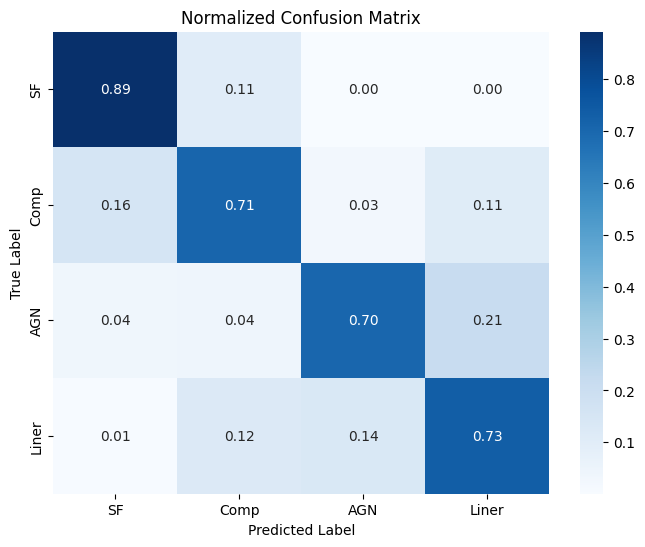

              precision    recall  f1-score   support

          SF       0.93      0.89      0.91      1179
        Comp       0.66      0.71      0.68       424
         AGN       0.77      0.70      0.74       183
       Liner       0.60      0.73      0.66       176

    accuracy                           0.82      1962
   macro avg       0.74      0.76      0.75      1962
weighted avg       0.83      0.82      0.82      1962

Balanced Accuracy: 0.7598029141924412


In [13]:
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score

#calculate accuracy
from sklearn.metrics import accuracy_score
y_pred_argmax = y_pred_adjusted
y_true = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true, y_pred_argmax)
print("Overall accuracy: ", accuracy)

#calculate confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred_argmax)

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
labels = ['SF', 'Comp', 'AGN', 'Liner']

# print per-class accuracy
for i, acc in enumerate(per_class_accuracy):
    print(f"Accuracy for class {labels[i]}: {acc:.4f} \n")

# normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.savefig("../plots/RF-confusion_matrix.png")
plt.show()

# print out full classification report
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred_argmax, target_names=labels))

balanced_acc = balanced_accuracy_score(y_true, y_pred_argmax)
print("Balanced Accuracy:", balanced_acc)

In [5]:
#save model, it is not included in the git repository because it becomes too heavy to push
import joblib
joblib.dump(rf_classifier, "random_forest_model.pkl")


['random_forest_model.pkl']

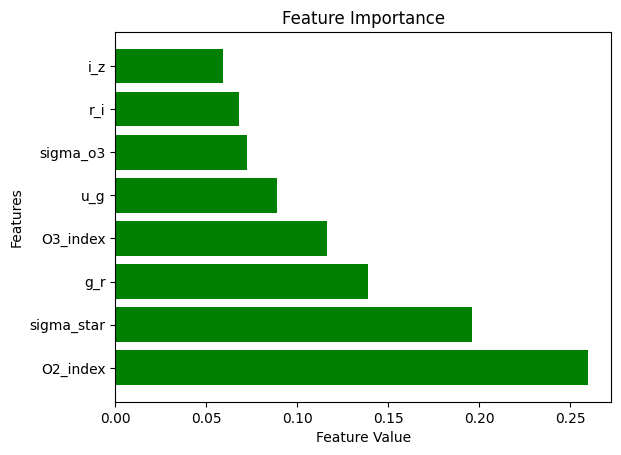

In [14]:
#feature names for importance classification
feature = ['O3_index', 'O2_index', 'sigma_star', 'sigma_o3', 'u_g', 'g_r', 'r_i', 'i_z']
importances = rf_classifier.feature_importances_
indices = np.argsort(importances)[::-1]
ordered_feature_names = []
ordered_feature_values = []
for i in indices:
    ordered_feature_names.append(feature[i])
    ordered_feature_values.append(importances[i])

#plot horizontal bar graph of feature importance
plt.barh(ordered_feature_names, ordered_feature_values, color='green')

plt.xlabel('Feature Value')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.savefig('../plots/RF_feature_importance.pdf',format='pdf')
plt.show()



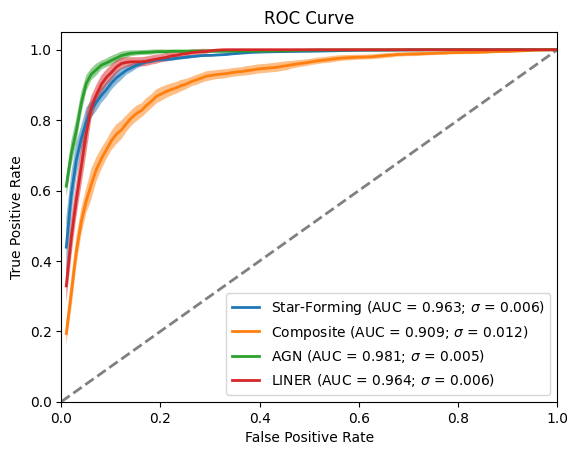

In [15]:
#calculate uncertianty of the model using bootstrap method
#this is done by resampling the data and training/fitting the model to the resampled data
#this is done 25 times and the mean and standard deviation of the predictions are calculated
#this is done for each class and the results are plotted

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample
import numpy as np
from scipy.interpolate import interp1d
import warnings

warnings.filterwarnings("ignore")

fpr = {}
tpr = {}
roc_auc = {}

plt.figure()

classes = ['Star-Forming', 'Composite', 'AGN', 'LINER']

# calculate ROC curves and AUC for each class
for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

#set-up plot 
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

#choose number of times to resample data, train model and test performance
#this is done 25 times and takes roughly 15 minutes

n_bootstraps = 25
#random state for reproducibility
rng = np.random.RandomState(42)


all_fprs = {i: [] for i in range(4)}
all_tprs = {i: [] for i in range(4)}

#create grid of false positive rates
mean_fpr_interpolated = np.linspace(0, 1, 100)

for i in range(4):
    for _ in range(n_bootstraps):
        #resample data
        X_resampled, y_resampled = resample(x_test, y_test, random_state=rng)
        #train model on resampled data
        rf_classifier.fit(x_train, y_train)
        #calculate probabilities for the resampled data
        y_prob_resampled = rf_classifier.predict_proba(X_resampled)
        
        fpr_resampled, tpr_resampled, _ = roc_curve(y_resampled[:, i], y_prob_resampled[:, i])
        
        f_interp = interp1d(fpr_resampled, tpr_resampled, kind='linear', fill_value="extrapolate")
        tpr_interpolated = f_interp(mean_fpr_interpolated)
        
        all_fprs[i].append(mean_fpr_interpolated)
        all_tprs[i].append(tpr_interpolated)

#plot the resulting mean ROC curves with uncertainity bands
for i in range(4):
    
    all_fprs[i] = np.array(all_fprs[i])
    all_tprs[i] = np.array(all_tprs[i])
    
    #average all ROC curves to get mean curve
    mean_tpr = np.mean(all_tprs[i], axis=0)
    mean_fpr = mean_fpr_interpolated  

    #standard deviation of the ROC curves for uncertainty
    std_tpr = np.std(all_tprs[i], axis=0)
    nan_to_zero = np.where(np.isnan(std_tpr), 0, std_tpr)
    std_tpr = nan_to_zero

    
    plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,alpha=0.5)
    
    
    plt.plot(mean_fpr, mean_tpr, label=rf'{classes[i]} (AUC = {roc_auc[i]:.3f}; $\sigma$ = {np.mean(std_tpr):.3f})', lw=2)

plt.legend(loc='lower right')
plt.savefig('../plots/RF_ROC_curve.pdf',format='pdf')
plt.show()

# Testing on Intermediate Redshift Galaxies

In [16]:
#open new data
file_path_features = '../data/X_extra_data.npy'
X_test = np.load(file_path_features)
file_path_labels = '../data/labels_extra_data.npy'
Y_test = np.load(file_path_labels)
Y_test = np.array(Y_test, dtype=int)

In [17]:
#predict probabilities for the new data
y_pred_new = rf_classifier.predict_proba(X_test)

In [19]:
#calculate accuracy
from sklearn.metrics import accuracy_score
y_pred = np.argmax(y_pred_new, axis=1)
y_true = np.argmax(Y_test, axis=1)
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy: ", accuracy)

#calculate confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_pred, y_true)

Accuracy:  0.7467532467532467


array([[108,  21,   4,   1],
       [ 11,   5,   0,   1],
       [  0,   1,   2,   0],
       [  0,   0,   0,   0]])

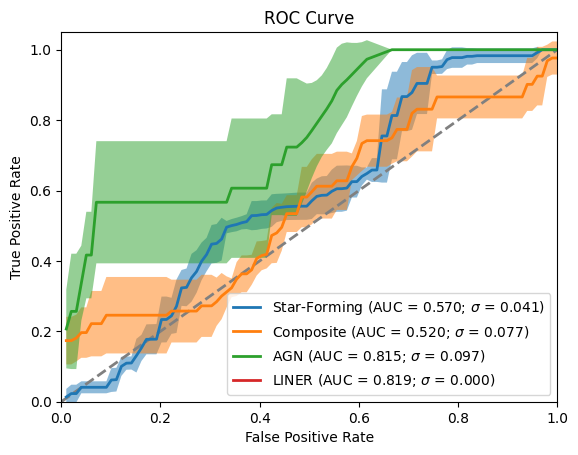

In [ ]:
#calculates ROC curves, AUC and uncertainty using the bootstrap method
#looks very similar to the previous code, but uses the new data. see above for more detailed comments 

y_pred_prob = np.array(y_pred_new)

fpr = {}
tpr = {}
roc_auc = {}

plt.figure()

classes = ['Star-Forming', 'Composite', 'AGN', 'LINER']
for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

#the results are terrible so to make the coding faster we limit here to 5 bootstraps
n_bootstraps = 5
rng = np.random.RandomState(42)


all_fprs = {i: [] for i in range(4)}
all_tprs = {i: [] for i in range(4)}

mean_fpr_interpolated = np.linspace(0, 1, 100)

for i in range(4):
    for _ in range(n_bootstraps):

        X_resampled, y_resampled = resample(X_test, Y_test, random_state=rng)
    
        #cannot re-train the model every iteration as we only have a test set, so it only calculates the probabilities of resampled set
        
        y_prob_resampled = rf_classifier.predict_proba(X_resampled)
        
        fpr_resampled, tpr_resampled, _ = roc_curve(y_resampled[:, i], y_prob_resampled[:, i])
        
        f_interp = interp1d(fpr_resampled, tpr_resampled, kind='linear', fill_value="extrapolate")
        tpr_interpolated = f_interp(mean_fpr_interpolated)
        
        all_fprs[i].append(mean_fpr_interpolated)
        all_tprs[i].append(tpr_interpolated)

for i in range(4):
    
    all_fprs[i] = np.array(all_fprs[i])
    all_tprs[i] = np.array(all_tprs[i])
    
    
    mean_tpr = np.mean(all_tprs[i], axis=0)
    mean_fpr = mean_fpr_interpolated  

    
    std_tpr = np.std(all_tprs[i], axis=0)
    nan_to_zero = np.where(np.isnan(std_tpr), 0, std_tpr)
    std_tpr = nan_to_zero

    
    plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,alpha=0.5)
    
    
    plt.plot(mean_fpr, mean_tpr, label=rf'{classes[i]} (AUC = {roc_auc[i]:.3f}; $\sigma$ = {np.mean(std_tpr):.3f})', lw=2)

plt.legend(loc='lower right')
plt.savefig('../plots/RF_ROC_curve.pdf',format='pdf')
plt.show()